# 1.1 線形モデル（2/4）特徴選択とベイズ回帰

**原典**: scikit-learn User Guide [1.1. Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) の 1.1.7〜1.1.10（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・特徴を 1 つずつ足していく回帰（LARS / OMP）の考え方を説明できる<br>・「Lasso の解の道筋」を LARS で一度に得られる理由を知る<br>・ベイズ回帰が「正則化の強さを自分で決める」仕組みをつかむ<br>・予測に「どれくらい自信があるか」（不確かさ）を付ける |
| **前提** | [1/4 最小二乗法と正則化](./01_linear_models_1_ols_regularization.ipynb)（Ridge / Lasso / 正則化パス） |
| **目安時間** | 45〜60 分 |

記号の意味は 1/4 と同じです（📖 ガイドの解説 / 💡 補足 / 🧪 やってみよう / 👀 結果の読み方 / ⚠️ つまずきポイント）。

### 目次

1. 1.1.7 最小角回帰（LARS）
2. 1.1.8 LARS Lasso
3. 1.1.9 直交マッチング追跡（OMP）
4. 1.1.10 ベイズ回帰（Bayesian Ridge / ARD）
5. まとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は上から順に実行してください。

このノートでは、scikit-learn に付属する**糖尿病データセット**（`load_diabetes`）を主に使います。442 人の患者について、年齢・性別・BMI・血圧・血液検査の値 6 種（計 10 個の特徴）から、1 年後の病気の進行度（数値）を予測するデータです。特徴はあらかじめ標準化（平均 0、大きさをそろえる処理）されています。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X_d, y_d = diabetes.data, diabetes.target
names = diabetes.feature_names
print("X の形:", X_d.shape, "/ 特徴名:", names)

X の形: (442, 10) / 特徴名: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


---
## 1. 最小角回帰 LARS（1.1.7 Least Angle Regression）

**ねらい**: 「特徴を 1 つずつ仲間に入れていく」回帰の考え方をつかむ。

### 📖 ガイドの解説

最小角回帰（LARS）は、Efron・Hastie・Johnstone・Tibshirani が考案した、**高次元データ向け**の回帰アルゴリズムです。前進ステップワイズ回帰に似ていて、各ステップで**目的変数といちばん相関の強い特徴**を見つけます。相関の強さが同じ特徴が複数あるときは、1 つの特徴の方向に進み続けるのではなく、**それらの特徴と等しい角度の方向**（等角方向）に進みます。

**利点**

- 特徴数がサンプル数よりずっと多い場合に、数値的に効率が良い。
- 前進選択と同じくらい速く、計算量は最小二乗法と同じオーダー。
- **区分的に線形な解の全経路（パス）**が得られる。交差検証などでモデルを調整するときに便利。
- 2 つの特徴が目的変数とほぼ同じくらい相関していれば、係数もほぼ同じ速さで増える。直感どおりに動き、安定している。
- 少し変えるだけで、Lasso などほかの推定器の解も得られる（→ 1.1.8）。

**欠点**

- 残差（まだ説明できていない部分）に繰り返し当てはめ直す方式なので、**ノイズの影響を特に受けやすい**と考えられる。

使うときは推定器 `Lars`、または低レベル関数 `lars_path` / `lars_path_gram` を使います。

### 💡 補足: チーム編成のたとえ

目的変数を「達成したい仕事」、特徴を「候補メンバー」と考えます。

1. 最初は誰も係数を持っていない（全員 0）。
2. 仕事にいちばん合っている（相関が強い）メンバーを入れ、その人の係数を少しずつ増やす。
3. 増やすにつれて「残りの仕事」が変わり、やがて別のメンバーの相性が、今のメンバーと同じくらいになる。
4. そこで 2 人目を入れ、**2 人の相性が同じまま保たれる方向**（等角方向）に一緒に係数を増やす。
5. これを繰り返し、全員が入ると最小二乗法の解にたどり着く。

「最小角」という名前は、残差との角度（相関）がいちばん小さい方向へ進むことに由来します。

### 🧪 やってみよう: 糖尿病データで LARS の道筋を描く

特徴が加わった順番: ['bmi', 's5', 'bp', 's3', 'sex', 's6', 's1', 's4', 's2', 'age']
coefs_lar の形: (10, 11) （特徴数, ステップ数 + 1）


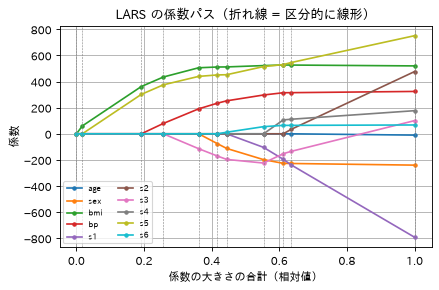

In [2]:
alphas_lar, active_lar, coefs_lar = lm.lars_path(X_d, y_d, method="lar")

print("特徴が加わった順番:", [names[i] for i in active_lar])
print("coefs_lar の形:", coefs_lar.shape, "（特徴数, ステップ数 + 1）")

# 横軸は「係数の絶対値の合計」を最終値で割ったもの（0 = 全係数が 0, 1 = 最小二乗解）
xx = np.abs(coefs_lar).sum(axis=0); xx /= xx[-1]
plt.plot(xx, coefs_lar.T, marker=".")
for v in xx: plt.axvline(v, color="gray", lw=0.5, ls="--")
plt.xlabel("係数の大きさの合計（相対値）"); plt.ylabel("係数")
plt.legend(names, fontsize=7, ncol=2); plt.title("LARS の係数パス（折れ線 = 区分的に線形）"); plt.show()

### 👀 結果の読み方

- 縦の点線が、**新しい特徴が仲間入りした瞬間**です。最初に BMI（`bmi`）、次に `s5`（血清中の中性脂肪に関する値）が入っています。
- 点線と点線の間は、係数が**まっすぐ**変化しています。これが「区分的に線形」の意味です。折れ曲がる点だけ計算すればパス全体が分かるので、効率が良いのです。
- 右端（相対値 1）は、正則化なしの最小二乗解と同じです。

In [3]:
ols_coef = lm.LinearRegression().fit(X_d, y_d).coef_
print("LARS の最後の係数と最小二乗解が一致:", np.allclose(coefs_lar[:, -1], ols_coef))

LARS の最後の係数と最小二乗解が一致: True


---
## 2. LARS Lasso（1.1.8）

**ねらい**: LARS を少し変えると、Lasso の**厳密な**解のパスが得られることを確かめる。

### 📖 ガイドの解説

`LassoLars` は、Lasso を LARS アルゴリズムで解く実装です。座標降下法による実装（`Lasso`）と違って**厳密解**を返し、その解は係数のノルムについて区分的に線形です。

In [4]:
reg = lm.LassoLars(alpha=.1)
reg.fit([[0, 0], [1, 1]], [0, 1])
print("coef_ =", reg.coef_)
assert np.allclose(reg.coef_, [0.6, 0.0])   # ガイドの出力: array([0.6, 0.])

coef_ = [0.6 0. ]


📖 LARS はパス全体を**ほぼ追加コストなしで**計算できるので、`lars_path` や `lars_path_gram` でパスを取り出すのがよくある使い方です。

**数式での説明（ガイドの Mathematical formulation）**: 前進ステップワイズ回帰に似ていますが、各ステップで特徴を丸ごと入れるのではなく、各特徴と残差の相関に対して**等しい角度の方向**に係数を増やします。結果はベクトル 1 つではなく、パラメータの L1 ノルムの各値に対する解を表す**曲線**です。係数のパス全体は `coef_path_`（形 `(n_features, max_features + 1)`）に保存され、**最初の列は常に 0** です。

### 💡 補足: LARS と Lasso はどこが違うのか

LARS のパスをそのまま使うと、途中で係数が **0 を横切ってプラスからマイナスへ**変わることがあります。Lasso のルールでは、係数が 0 に達したらその特徴は**いったん外す**必要があります。`method="lasso"` はこの修正を加えたもので、これだけで Lasso の厳密なパスになります。

### 🧪 やってみよう: 2 つのパスを比べる

LARS  のステップ数: 10
Lasso のステップ数: 12
LARS で 0 を横切った特徴: ['s3']


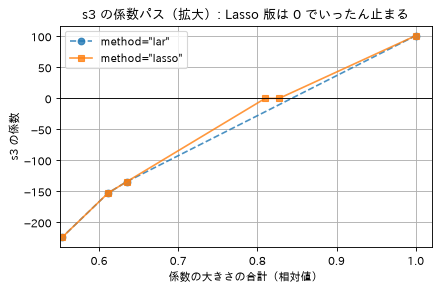

In [5]:
alphas_ls, active_ls, coefs_ls = lm.lars_path(X_d, y_d, method="lasso")
print("LARS  のステップ数:", coefs_lar.shape[1] - 1)
print("Lasso のステップ数:", coefs_ls.shape[1] - 1)

# 係数の符号が途中で変わった（0 を横切った）特徴を探す
crossed = [j for j in range(len(names))
           if (np.sign(coefs_lar[j, 1:]) * np.sign(coefs_lar[j, :-1]) < 0).any()]
print("LARS で 0 を横切った特徴:", [names[j] for j in crossed])

# その特徴の係数だけを、2 つの方法で重ねて拡大表示する
j = crossed[0]
for c, style, label in [(coefs_lar, "o--", 'method="lar"'), (coefs_ls, "s-", 'method="lasso"')]:
    x_ = np.abs(c).sum(axis=0); x_ /= x_[-1]
    plt.plot(x_, c[j], style, label=label, alpha=0.8)
plt.axhline(0, color="black", lw=0.8)
plt.xlim(0.55, 1.02); plt.xlabel("係数の大きさの合計（相対値）"); plt.ylabel(f"{names[j]} の係数")
plt.legend(); plt.title(f"{names[j]} の係数パス（拡大）: Lasso 版は 0 でいったん止まる"); plt.show()

### 👀 結果の読み方

- `method="lasso"` のほうがステップが 2 つ多くなっています。0 を横切りそうになった特徴を**いったん外して、あとで入れ直す**ステップが増えたためです。
- 図は、LARS で 0 を横切った特徴 `s3` の係数だけを拡大したものです。`method="lar"`（点線）はマイナスからプラスへ、0 をそのまま通り抜けています。`method="lasso"`（実線）は 0 に達したところで**いったん外れて 0 に張り付き**、少し進んでから入り直しています。この「外して入れ直す」2 ステップが、ステップ数の差です。
- 張り付いている区間は短いので、全特徴のパスを並べた図ではほとんど見分けがつきません。違いは小さくても、Lasso の定義（係数が 0 を越えて符号を変えない）を守るために必要な修正です。

### 🧪 やってみよう: 座標降下法の `Lasso` と同じ答えになるか

`LassoLars`（LARS で厳密に解く）と `Lasso`（座標降下法で近似的に解く）を、同じ `alpha` で比べます。

In [6]:
rows = []
for a in [0.01, 0.1, 0.5]:
    c_lars = lm.LassoLars(alpha=a).fit(X_d, y_d).coef_
    c_cd = lm.Lasso(alpha=a, tol=1e-10, max_iter=100_000).fit(X_d, y_d).coef_
    rows.append({"alpha": a, "係数の最大の差": np.abs(c_lars - c_cd).max(),
                 "0 でない係数（LassoLars）": (c_lars != 0).sum(), "0 でない係数（Lasso）": (c_cd != 0).sum()})
pd.DataFrame(rows).set_index("alpha")

,係数の最大の差,0 でない係数（LassoLars）,0 でない係数（Lasso）
alpha,,,
0.01,3.2507e-06,10,10
0.10,4.6080e-08,7,7
0.50,3.2249e-09,4,4


👀 解き方が違っても、同じ問題の同じ答えにたどり着いています。`coef_path_` の形も確かめておきます。

In [7]:
m = lm.LassoLars(alpha=0.0).fit(X_d, y_d)   # alpha=0 まで進めるとパス全体が得られる
print("coef_path_ の形:", m.coef_path_.shape)
print("最初の列はすべて 0:", (m.coef_path_[:, 0] == 0).all())

coef_path_ の形: (10, 13)
最初の列はすべて 0: True


> 💡 **どちらを使うか**: 特徴数がサンプル数よりずっと多いときや、パス全体が欲しいときは `LassoLars` / `lars_path`。特徴もサンプルも多い普通のデータでは、座標降下法の `Lasso` がふつうは速く、1/4 で見たように相関の強い特徴が多いときも `LassoCV` が勧められています。

---
## 3. 直交マッチング追跡 OMP（1.1.9 Orthogonal Matching Pursuit）

**ねらい**: 「0 でない係数の**個数**」を直接指定する方法を知る。

### 📖 ガイドの解説

`OrthogonalMatchingPursuit` と `orthogonal_mp` は、**0 でない係数の数**に制約を付けて線形モデルを当てはめる OMP アルゴリズムの実装です（L0 疑似ノルムによる制約）。LARS と同じ前進的な特徴選択の方法で、決まった個数の非ゼロ要素を持つ最適解を近似できます。

$$\underset{w}{\arg\min} \ \| y - X w \|_2^2 \quad \text{subject to} \quad \| w \|_0 \le n_{\text{nonzero\_coefs}}$$

代わりに、**誤差の許容量**を指定することもできます。

$$\underset{w}{\arg\min} \ \| w \|_0 \quad \text{subject to} \quad \| y - X w \|_2^2 \le \text{tol}$$

OMP は貪欲法です。各ステップで、**今の残差といちばん相関の強い原子**（辞書の要素＝特徴の列）を加えます。単純なマッチング追跡（MP）と似ていますが、毎回、それまでに選んだ要素が作る空間への**直交射影**で残差を計算し直す点で優れています。

### 💡 補足: L0「ノルム」と、Lasso との違い

$\|w\|_0$ は「0 でない要素の数」です（厳密にはノルムの条件を満たさないので「疑似ノルム」と呼びます）。

- Lasso: 「係数の絶対値の合計」に罰をかける。結果として 0 が増えるが、**何個になるかは `alpha` 次第**
- OMP: 「**ちょうど k 個まで**使ってよい」と個数で指定する。係数そのものは縮めない

「説明に使う特徴は 3 個まで」のように、ルールとして個数を決めたいときに便利です。

### 🧪 やってみよう: 個数を指定して特徴を選ぶ

In [8]:
rows = []
for k in range(1, 6):
    c = lm.OrthogonalMatchingPursuit(n_nonzero_coefs=k).fit(X_d, y_d).coef_
    rows.append({"n_nonzero_coefs": k, "選ばれた特徴": ", ".join(names[i] for i in np.flatnonzero(c))})
pd.DataFrame(rows).set_index("n_nonzero_coefs")

,選ばれた特徴
n_nonzero_coefs,
1,bmi
2,"bmi, s5"
3,"bmi, bp, s5"
4,"bmi, bp, s3, s5"
5,"sex, bmi, bp, s3, s5"


👀 指定した個数ぴったりの特徴が選ばれました。`bmi`, `s5`, `bp` と、LARS が最初に選んだ特徴とよく似た顔ぶれです。

### 🧪 やってみよう: ガイドの例「まばらな信号の復元」

ガイドの例（Orthogonal Matching Pursuit）と同じ設定です。512 個の候補（辞書の原子）のうち、**17 個だけ**が使われた信号を作ります。観測は 100 次元しかありません。未知数（512）が観測数（100）より多いので、普通の最小二乗法では解が 1 つに決まりません。それでも「17 個しか使っていない」ことを手がかりに、元の係数を当てられるかを試します。

X の形: (100, 512) / 正解の非ゼロ数: 17


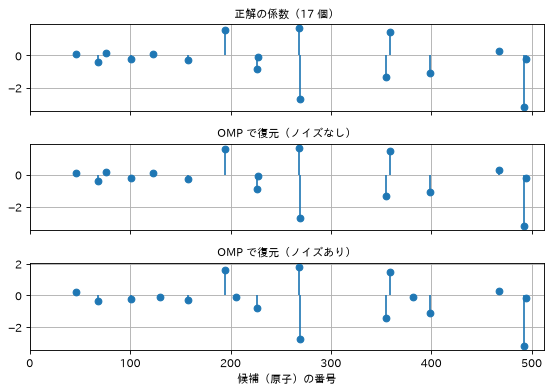

In [9]:
from sklearn.datasets import make_sparse_coded_signal
y_sig, dictionary, w_true = make_sparse_coded_signal(
    n_samples=1, n_components=512, n_features=100, n_nonzero_coefs=17, random_state=0)
X_sig = dictionary.T                       # 形 (100, 512): 観測 100 個、候補 512 個
print("X の形:", X_sig.shape, "/ 正解の非ゼロ数:", (w_true != 0).sum())

y_noisy = y_sig + 0.05 * np.random.RandomState(1).randn(len(y_sig))
fig, axes = plt.subplots(3, 1, figsize=(7, 5), sharex=True)
for ax, (title, w) in zip(axes, [
        ("正解の係数（17 個）", w_true),
        ("OMP で復元（ノイズなし）", lm.OrthogonalMatchingPursuit(n_nonzero_coefs=17).fit(X_sig, y_sig).coef_),
        ("OMP で復元（ノイズあり）", lm.OrthogonalMatchingPursuit(n_nonzero_coefs=17).fit(X_sig, y_noisy).coef_)]):
    idx = np.flatnonzero(w)
    ax.stem(idx, w[idx], basefmt=" "); ax.set_title(title, fontsize=10); ax.set_xlim(0, 512)
axes[-1].set_xlabel("候補（原子）の番号"); plt.tight_layout(); plt.show()

In [10]:
w_hat = lm.OrthogonalMatchingPursuit(n_nonzero_coefs=17).fit(X_sig, y_sig).coef_
print("ノイズなし: 位置がすべて正解と一致:", set(np.flatnonzero(w_hat)) == set(np.flatnonzero(w_true)),
      "/ 係数の最大誤差:", np.abs(w_hat - w_true).max().round(6))
w_hat_n = lm.OrthogonalMatchingPursuit(n_nonzero_coefs=17).fit(X_sig, y_noisy).coef_
hit = len(set(np.flatnonzero(w_hat_n)) & set(np.flatnonzero(w_true)))
print(f"ノイズあり: 17 個中 {hit} 個の位置が正解と一致")

ノイズなし: 位置がすべて正解と一致: True / 係数の最大誤差: 0.0
ノイズあり: 17 個中 14 個の位置が正解と一致


### 👀 結果の読み方

- ノイズがなければ、100 個の観測から 512 個の未知数のうち**どの 17 個が使われたか**を完全に当て、値もほぼ正確に復元できました。「ほとんどが 0」という前提（スパース性）が、足りない情報を補っているのです。これが圧縮センシングの考え方です。
- ノイズがあっても、位置はよく当たっています（上の出力の個数を参照）。値は少しずれます。

> 💡 実際の応用例: 音声や画像を、少数の基本パターン（辞書）の組み合わせで表す「スパース符号化」で使われます。

---
## 4. ベイズ回帰（1.1.10 Bayesian Regression）

**ねらい**: 正則化の強さを「人が決める」のではなく「データから決める」考え方と、予測の不確かさの出し方を知る。

### 💡 補足: ベイズの考え方を 1 分で

ベイズ統計では、パラメータ（ここでは係数 $w$）を「決まった 1 つの値」ではなく、**確率分布**（どの値がどのくらいありそうか）で表します。

1. **事前分布**: データを見る前の思い込み。例: 「係数はたぶん 0 の近くだろう」
2. **データ**を見る
3. **事後分布**: データで思い込みを更新した結果。例: 「係数は 25 前後、±3 くらいだろう」

たとえるなら、口コミ評価が数件しかない新しいお店を「たぶん平均的なお店だろう」と見ておき、口コミが増えるにつれて実際の評価に寄せていくようなものです。**データが少ないうちは事前の思い込み（0 付近）に強く引き寄せられる**。これは Ridge の「係数を 0 に縮める」とまったく同じ働きです。

### 📖 ガイドの解説

ベイズ回帰の手法を使うと、正則化パラメータを推定の手順に組み込めます。正則化パラメータを固定値として決めるのではなく、**手元のデータに合わせて調整**します。そのために、モデルのハイパーパラメータに**無情報事前分布**（特に何も仮定しない分布）を置きます。

Ridge の L2 正則化は、係数 $w$ に精度 $\lambda^{-1}$ の**ガウス事前分布**を置いたときの**最大事後確率（MAP）推定**と等価です。$\lambda$ を手で決める代わりに、**確率変数として扱ってデータから推定**できます。

完全な確率モデルにするため、出力 $y$ は $Xw$ のまわりにガウス分布すると仮定します。

$$p(y \mid X, w, \alpha) = \mathcal{N}(y \mid X w, \alpha^{-1})$$

ここで $\alpha$（ノイズの精度）も、データから推定する確率変数として扱います。

- 利点: 手元のデータに適応する / 正則化パラメータを推定手順に含められる
- 欠点: モデルの推論に時間がかかることがある

> ⚠️ **記号の注意**: ここでの $\alpha$ は**ノイズの精度**（分散の逆数）で、Ridge の `alpha`（正則化の強さ）とは**別物**です。紛らわしいので気をつけてください。$\lambda$ が「係数の精度」で、こちらが Ridge の正則化の強さに対応します。

### 1.1.10.1 Bayesian Ridge

📖 `BayesianRidge` は、上で説明した確率モデルを推定します。係数 $w$ の事前分布は、球状のガウス分布です。

$$p(w \mid \lambda) = \mathcal{N}(w \mid 0, \lambda^{-1} \mathbf{I}_p)$$

$\alpha$ と $\lambda$ の事前分布には、ガウス分布の精度の共役事前分布であるガンマ分布を選びます。こうして得られるモデルを Bayesian Ridge 回帰と呼び、古典的な Ridge に似ています。

$w$、$\alpha$、$\lambda$ は学習中に同時に推定されます。正則化パラメータ $\alpha$ と $\lambda$ は、**対数周辺尤度を最大化**して決めます（Tipping 2001 の付録 A のアルゴリズムと、MacKay 1992 の更新式）。最大化の初期値は `alpha_init` と `lambda_init` で指定できます。ガンマ事前分布の 4 つのハイパーパラメータ $\alpha_1, \alpha_2, \lambda_1, \lambda_2$ は、ふつう無情報になるように選び、既定値はすべて $10^{-6}$ です。

### 🧪 やってみよう: ガイドのコード例

In [11]:
X = [[0., 0.], [1., 1.], [2., 2.], [3., 3.]]
Y = [0., 1., 2., 3.]
reg = lm.BayesianRidge()
reg.fit(X, Y)
print("predict([[1, 0.]]) =", reg.predict([[1, 0.]]))
print("coef_ =", reg.coef_)
assert np.allclose(reg.predict([[1, 0.]]), [0.50000013], atol=1e-6)   # ガイドの出力と一致

predict([[1, 0.]]) = [0.5]
coef_ = [0.5 0.5]


📖 ベイズの枠組みのため、得られる係数は最小二乗法とわずかに異なります（最小二乗法なら厳密に 0.5）。その代わり、Bayesian Ridge は**不良設定問題**（解が 1 つに定まらない・不安定な問題）に強くなります。

### 🧪 やってみよう: Bayesian Ridge は「正則化の強さを自分で選んだ Ridge」

糖尿病データで学習し、推定された $\alpha$（ノイズの精度）と $\lambda$（係数の精度）を見ます。数式を追うと、Bayesian Ridge の係数は `Ridge(alpha = λ / α)` の係数と一致するはずです。

In [12]:
br = lm.BayesianRidge().fit(X_d, y_d)
ridge_equiv = lm.Ridge(alpha=br.lambda_ / br.alpha_).fit(X_d, y_d)
print(f"推定された alpha_（ノイズの精度） = {br.alpha_:.3g}  → ノイズの標準偏差 ≈ {1 / np.sqrt(br.alpha_):.1f}")
print(f"推定された lambda_（係数の精度） = {br.lambda_:.3g}")
print(f"対応する Ridge の alpha = lambda_ / alpha_ = {br.lambda_ / br.alpha_:.4f}")
print("Ridge(alpha=lambda_/alpha_) と係数が一致:", np.allclose(br.coef_, ridge_equiv.coef_))
print("RidgeCV が交差検証で選んだ alpha:", "%.4f" % lm.RidgeCV(alphas=np.logspace(-4, 2, 61)).fit(X_d, y_d).alpha_)

推定された alpha_（ノイズの精度） = 0.000341  → ノイズの標準偏差 ≈ 54.2
推定された lambda_（係数の精度） = 1.15e-05
対応する Ridge の alpha = lambda_ / alpha_ = 0.0336
Ridge(alpha=lambda_/alpha_) と係数が一致: True
RidgeCV が交差検証で選んだ alpha: 0.0040


### 👀 結果の読み方

- Bayesian Ridge の係数は、`Ridge(alpha=λ/α)` と完全に一致しました。つまり中身は **Ridge そのもの**で、正則化の強さ `alpha` を**周辺尤度の最大化という別の方法で自動的に選んでいる**だけです。
- 交差検証（`RidgeCV`）が選んだ `alpha`（0.004）とは約 8 倍違います。周辺尤度は「データ全体をどれだけうまく説明できるか」、交差検証は「見ていないデータをどれだけ当てられるか」を基準にしているので、選ぶ値は一致しません。どちらも「正則化はかなり弱めでよい」と判断している点は共通です。
- 推定されたノイズの標準偏差（約 54）は、「このデータの進行度は、どうしても ±54 くらいは外れる」という見積もりです。

### 🧪 やってみよう: 予測に「自信の幅」を付ける

ベイズ回帰の大きな利点は、`predict(X, return_std=True)` で**予測の標準偏差**も得られることです。1 次元の例で、データがある場所とない場所で幅がどう違うかを見ます。

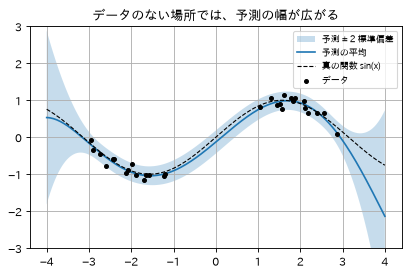

In [13]:
rng = np.random.RandomState(3)
x_b = np.r_[rng.uniform(-3, -1, 15), rng.uniform(1, 3, 15)]   # 真ん中 (-1〜1) にはデータがない
y_b = np.sin(x_b) + 0.1 * rng.randn(30)

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=5, include_bias=False)
model_b = lm.BayesianRidge().fit(poly.fit_transform(x_b[:, None]), y_b)

x_grid = np.linspace(-4, 4, 200)
mean, std = model_b.predict(poly.transform(x_grid[:, None]), return_std=True)
plt.fill_between(x_grid, mean - 2 * std, mean + 2 * std, alpha=0.25, label="予測 ± 2 標準偏差")
plt.plot(x_grid, mean, label="予測の平均"); plt.plot(x_grid, np.sin(x_grid), "k--", lw=1, label="真の関数 sin(x)")
plt.scatter(x_b, y_b, s=12, c="black", zorder=3, label="データ")
plt.ylim(-3, 3); plt.legend(fontsize=8); plt.title("データのない場所では、予測の幅が広がる"); plt.show()

👀 データのある場所では帯が細く、データの範囲の外側（x < −3、x > 3）では**帯が大きく広がって**います。モデルが「ここはよく分からない」と正直に言っているわけです。ふつうの `Ridge` や `LinearRegression` は予測値しか返さないので、この情報は得られません。

一方、真ん中の空白（−1〜1）では帯はわずかに広がる程度です。両側にデータがあるので、多項式がその間を**補間**でき、モデルにとっては「挟まれていて見当がつく場所」だからです。**外挿（データの範囲の外）は、補間より不確かさがずっと大きい**ことが分かります。

> ⚠️ **つまずきポイント**: この幅は「モデルの形（ここでは 5 次多項式）が正しい」という前提での自信です。範囲の外（x = ±4 付近）では真の関数から大きく外れていても、帯がそれを覆いきれていない場所があります。モデルの形そのものが間違っている可能性までは表せません。

### 1.1.10.2 ARD（Automatic Relevance Determination）

📖 ARD（`ARDRegression`）は Bayesian Ridge によく似た線形モデルですが、**よりスパースな係数** $w$ になります。

違いは係数の事前分布です。球状のガウス分布の代わりに、**軸ごとに幅の違う楕円状のガウス分布**を使います。つまり、係数 $w_i$ ごとに別々の精度 $\lambda_i$ を持ちます。

$$p(w \mid \lambda) = \mathcal{N}(w \mid 0, A^{-1}), \qquad \operatorname{diag}(A) = \lambda = \{\lambda_1, \dots, \lambda_p\}$$

Bayesian Ridge ではすべての係数が同じ標準偏差を持ちますが、ARD では各係数が自分専用の標準偏差 $1 / \lambda_i$ を持ちます。すべての $\lambda_i$ の事前分布には、ハイパーパラメータ $\lambda_1, \lambda_2$ で決まる同じガンマ分布を使います。ARD は文献では**スパースベイズ学習**や**関連ベクトルマシン（RVM）**とも呼ばれます。

### 💡 補足: 係数ごとに「関連度」を自動判定する

Bayesian Ridge は「全員に同じ税率」、ARD は「**一人ずつ税率を決める**」やり方です。ある特徴の $\lambda_i$ が非常に大きくなる（その係数は 0 付近に強く縛られる）と、その特徴は事実上使われなくなります。これが「関連性の自動判定（Automatic Relevance Determination）」という名前の意味です。

### 🧪 やってみよう: 効く特徴が 2 個だけのデータで比べる

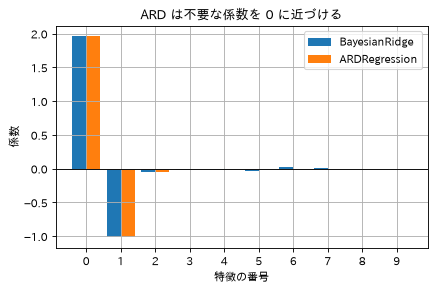

,BayesianRidge の係数,ARD の係数,ARD の lambda_（係数の精度）
特徴0（効く）,1.9608,1.9653,0.2589
特徴1（効く）,-1.0207,-1.0172,0.9654
特徴2,-0.0551,-0.0484,324.9525
特徴3,-0.0278,-0.0045,6655.4824
特徴4,-0.0188,0.0000,17565.3181
特徴5,-0.0384,-0.0028,8076.7972
特徴6,0.0160,0.0000,14667.3176
特徴7,0.0052,0.0000,43533.4244
特徴8,-0.0095,0.0000,27885.9480
特徴9,0.0004,0.0000,355020.4423


In [14]:
rng = np.random.RandomState(4)
X_a = rng.randn(100, 10)
y_a = 2 * X_a[:, 0] - X_a[:, 1] + 0.3 * rng.randn(100)   # 効くのは特徴 0 と 1 だけ

c_br = lm.BayesianRidge().fit(X_a, y_a).coef_
ard = lm.ARDRegression().fit(X_a, y_a)
idx = np.arange(10)
plt.bar(idx - 0.2, c_br, width=0.4, label="BayesianRidge")
plt.bar(idx + 0.2, ard.coef_, width=0.4, label="ARDRegression")
plt.axhline(0, color="black", lw=0.8); plt.xticks(idx)
plt.xlabel("特徴の番号"); plt.ylabel("係数"); plt.legend(); plt.title("ARD は不要な係数を 0 に近づける"); plt.show()

pd.DataFrame({"BayesianRidge の係数": c_br, "ARD の係数": ard.coef_, "ARD の lambda_（係数の精度）": ard.lambda_},
             index=[f"特徴{i}" + ("（効く）" if i < 2 else "") for i in idx])

### 👀 結果の読み方

- BayesianRidge は、効かない 8 個の特徴にも小さな係数を残しています。
- ARD は、効かない特徴の多くを **0** にしました。その特徴の `lambda_`（係数の精度）が非常に大きくなっている、つまり「この係数は 0 だと強く信じている」ことが表から分かります。
- ただし、効かない特徴がすべて 0 になるとは限りません（表で小さな値が残っている特徴を確認してください）。

📖 ガイドの例「Comparing Linear Bayesian Regressors」では ARD と Bayesian Ridge を詳しく比べ、「L1-based models for Sparse Signals」では相関のあるデータで Lasso・ARD・ElasticNet を比べています。

---
## 5. まとめ

### 手法の比較表

| 手法 | やっていること | 何を指定するか | 得られるもの |
|---|---|---|---|
| `Lars` / `lars_path` | 相関の強い特徴を 1 つずつ加え、等角方向に進む | （パス全体を計算） | 区分的に線形な係数パス |
| `LassoLars` | LARS に「0 になったら外す」修正を加えた Lasso | `alpha` | Lasso の厳密解 |
| `OrthogonalMatchingPursuit` | 残差と最も相関する特徴を貪欲に追加し、直交射影で残差を更新 | 非ゼロの**個数** or 許容誤差 | ちょうど k 個の特徴を使う解 |
| `BayesianRidge` | 係数にガウス事前分布。正則化の強さをデータから推定 | （基本は不要） | Ridge と同じ係数 + **予測の不確かさ** |
| `ARDRegression` | 係数ごとに別の精度を推定 | （基本は不要） | よりスパースな係数 |

### 覚えておきたい 3 つのこと

1. **LARS は「係数パスを丸ごと」安く計算する方法**。少し修正すると Lasso の厳密なパスになる。
2. **OMP は「使う特徴の数」を直接指定できる**。係数は縮めない。
3. **Bayesian Ridge の中身は Ridge**。違いは正則化の強さの決め方（周辺尤度の最大化）と、予測の不確かさが出せる点。

### 🧩 ドメインモデルの視点

- `BayesianRidge` の `predict` は、`return_std=True` を渡すと戻り値が**タプル**（平均, 標準偏差）に変わります。引数によって戻り値の型が変わるのは、Python らしい設計ですが、TypeScript なら関数のオーバーロード、Java なら別メソッドとして表現したくなるところです。
- `lars_path` や `orthogonal_mp` のように、**推定器クラスとは別に関数版**も用意されています。「状態を持つオブジェクト（Estimator）」と「状態を持たない純粋な関数」が並んでいるのは、scikit-learn の API の特徴です。

### ✅ 確認クイズ

**Q1.** LARS で、2 つの特徴の相関が同じになったとき、係数はどの方向に更新されますか。

<details><summary>答え</summary>

両方の特徴と等しい角度になる方向（等角方向）。2 つの特徴の係数が一緒に増えていきます。
</details>

**Q2.** `lars_path` の `method="lar"` と `method="lasso"` で、ステップ数が違うことがあるのはなぜですか。

<details><summary>答え</summary>

Lasso 版は、係数が 0 に達した特徴をいったん外すステップを入れるからです。LARS はそのまま符号をまたいで進みます。
</details>

**Q3.** 「説明に使う特徴をちょうど 3 個にしたい」とき、Lasso と OMP のどちらが向いていますか。

<details><summary>答え</summary>

OMP（`n_nonzero_coefs=3`）。Lasso は `alpha` で間接的にしか個数を調整できません。
</details>

**Q4.** `BayesianRidge` の学習結果 `alpha_` は、Ridge の `alpha` と同じ意味ですか。

<details><summary>答え</summary>

違います。`BayesianRidge.alpha_` はノイズの精度です。Ridge の正則化の強さに対応するのは `lambda_ / alpha_` です。
</details>

---
**前のノート**: [1/4 最小二乗法と正則化](./01_linear_models_1_ols_regularization.ipynb) ・ **次のノート**: [3/4 分類と一般化線形モデル](./01_linear_models_3_classification_glm.ipynb) — ロジスティック回帰, GLM, SGD